In [1]:
import pandas as pd
import numpy as np

print("Environment is ready!")

Environment is ready!


In [2]:
file_path = "../data/raw/LD2011_2014.txt"

df = pd.read_csv(
    file_path,
    sep=";",
    decimal=","
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (140256, 371)


In [3]:
print(df.head())
print("\nColumn names:")
print(df.columns[:10])

print("\nData types:")
print(df.dtypes.head(10))

print("\nMissing values:")
print(df.isnull().sum().sum())

            Unnamed: 0  MT_001  MT_002  MT_003  MT_004  MT_005  MT_006  \
0  2011-01-01 00:15:00     0.0     0.0     0.0     0.0     0.0     0.0   
1  2011-01-01 00:30:00     0.0     0.0     0.0     0.0     0.0     0.0   
2  2011-01-01 00:45:00     0.0     0.0     0.0     0.0     0.0     0.0   
3  2011-01-01 01:00:00     0.0     0.0     0.0     0.0     0.0     0.0   
4  2011-01-01 01:15:00     0.0     0.0     0.0     0.0     0.0     0.0   

   MT_007  MT_008  MT_009  ...  MT_361  MT_362  MT_363  MT_364  MT_365  \
0     0.0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0   
1     0.0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0   
2     0.0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0   
3     0.0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0   
4     0.0     0.0     0.0  ...     0.0     0.0     0.0     0.0     0.0   

   MT_366  MT_367  MT_368  MT_369  MT_370  
0     0.0     0.0     0.0     0.0     0.0  
1     0.0     0.0     

In [4]:
# Rename the timestamp column
df.rename(columns={"Unnamed: 0": "timestamp"}, inplace=True)

# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Check timestamp information
print("Timestamp type:", df["timestamp"].dtype)
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

# Check for duplicate timestamps
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

# Check the time interval
print("First 5 timestamps:")
print(df["timestamp"].head())

Timestamp type: datetime64[us]
Start: 2011-01-01 00:15:00
End: 2015-01-01 00:00:00
Duplicate timestamps: 0
First 5 timestamps:
0   2011-01-01 00:15:00
1   2011-01-01 00:30:00
2   2011-01-01 00:45:00
3   2011-01-01 01:00:00
4   2011-01-01 01:15:00
Name: timestamp, dtype: datetime64[us]


In [5]:
# Get all electricity consumption columns
consumption_columns = df.columns[1:]

# Calculate total electricity load
df["total_load"] = df[consumption_columns].sum(axis=1)

# Inspect the result
print(df[["timestamp", "total_load"]].head())

print("\nTotal load statistics:")
print(df["total_load"].describe())

            timestamp    total_load
0 2011-01-01 00:15:00  68513.115338
1 2011-01-01 00:30:00  69180.304361
2 2011-01-01 00:45:00  69364.850573
3 2011-01-01 01:00:00  68350.480660
4 2011-01-01 01:15:00  66166.874303

Total load statistics:
count    140256.000000
mean     195556.942526
std       84259.360145
min         342.595509
25%      131128.411567
50%      167856.513526
75%      248834.303388
max      452652.595567
Name: total_load, dtype: float64


C:\Users\nimra\AppData\Local\Temp\ipykernel_15768\4066773408.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["total_load"] = df[consumption_columns].sum(axis=1)


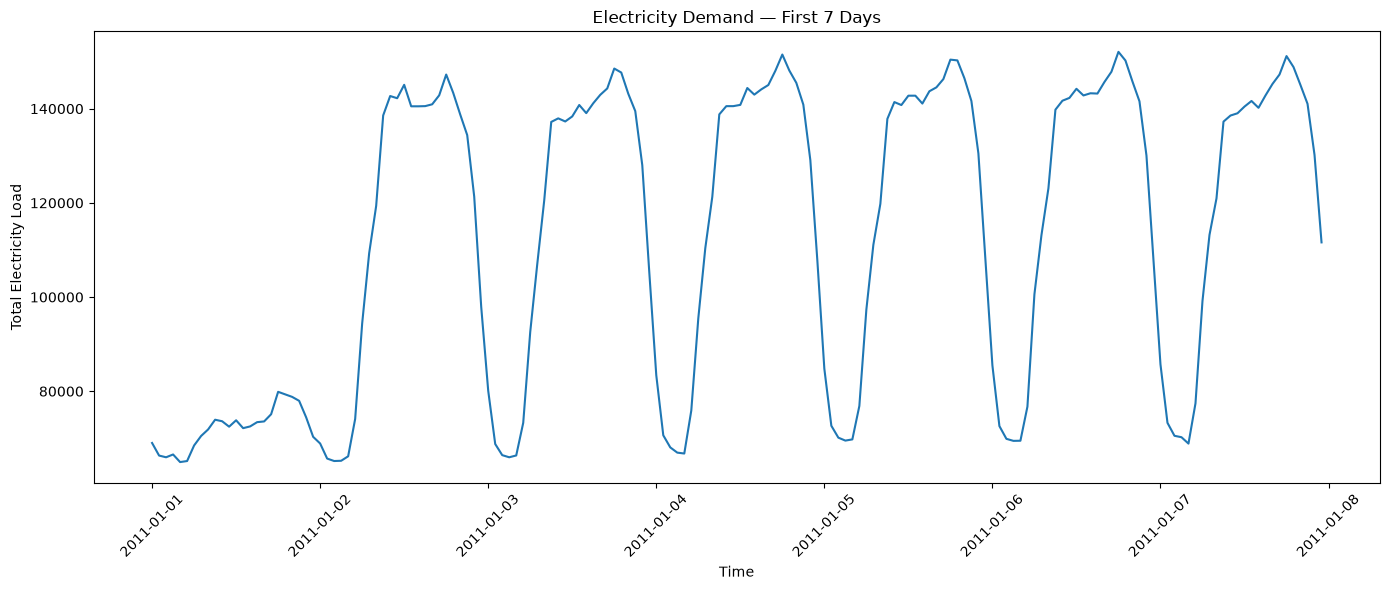

In [6]:
import matplotlib.pyplot as plt

# Create hourly total load
hourly_load = (
    df.set_index("timestamp")["total_load"]
    .resample("1h")
    .mean()
)

# Plot the first 7 days
plt.figure(figsize=(14, 6))
plt.plot(hourly_load.iloc[:24 * 7])

plt.title("Electricity Demand — First 7 Days")
plt.xlabel("Time")
plt.ylabel("Total Electricity Load")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Create time-based features
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["day_of_year"] = df["timestamp"].dt.dayofyear
df["month"] = df["timestamp"].dt.month
df["year"] = df["timestamp"].dt.year
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Check the new features
print(df[[
    "timestamp",
    "hour",
    "day_of_week",
    "day_of_year",
    "month",
    "year",
    "is_weekend"
]].head(10))

            timestamp  hour  day_of_week  day_of_year  month  year  is_weekend
0 2011-01-01 00:15:00     0            5            1      1  2011           1
1 2011-01-01 00:30:00     0            5            1      1  2011           1
2 2011-01-01 00:45:00     0            5            1      1  2011           1
3 2011-01-01 01:00:00     1            5            1      1  2011           1
4 2011-01-01 01:15:00     1            5            1      1  2011           1
5 2011-01-01 01:30:00     1            5            1      1  2011           1
6 2011-01-01 01:45:00     1            5            1      1  2011           1
7 2011-01-01 02:00:00     2            5            1      1  2011           1
8 2011-01-01 02:15:00     2            5            1      1  2011           1
9 2011-01-01 02:30:00     2            5            1      1  2011           1


C:\Users\nimra\AppData\Local\Temp\ipykernel_15768\2522549447.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hour"] = df["timestamp"].dt.hour
C:\Users\nimra\AppData\Local\Temp\ipykernel_15768\2522549447.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["day_of_week"] = df["timestamp"].dt.dayofweek
C:\Users\nimra\AppData\Local\Temp\ipykernel_15768\2522549447.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider

In [8]:
# Compare average electricity load on weekdays vs weekends

weekday_vs_weekend = df.groupby("is_weekend")["total_load"].mean()

print("Average load:")
print("Weekdays :", weekday_vs_weekend[0])
print("Weekends :", weekday_vs_weekend[1])

Average load:
Weekdays : 196159.20225944268
Weekends : 194054.12236001802


In [9]:
# Create lag features for forecasting

df["lag_1"] = df["total_load"].shift(1)
df["lag_4"] = df["total_load"].shift(4)
df["lag_96"] = df["total_load"].shift(96)

# Check the lag features
print(df[[
    "timestamp",
    "total_load",
    "lag_1",
    "lag_4",
    "lag_96"
]].head(105).tail(10))

              timestamp    total_load         lag_1         lag_4  \
95  2011-01-02 00:00:00  69252.968036  69252.986210  72164.815735   
96  2011-01-02 00:15:00  67894.331676  69252.968036  70288.522816   
97  2011-01-02 00:30:00  68874.780148  67894.331676  69592.364448   
98  2011-01-02 00:45:00  69598.309589  68874.780148  69252.986210   
99  2011-01-02 01:00:00  67345.334537  69598.309589  69252.968036   
100 2011-01-02 01:15:00  65553.522541  67345.334537  67894.331676   
101 2011-01-02 01:30:00  64480.813471  65553.522541  68874.780148   
102 2011-01-02 01:45:00  65452.308026  64480.813471  69598.309589   
103 2011-01-02 02:00:00  64839.519747  65452.308026  67345.334537   
104 2011-01-02 02:15:00  64812.327598  64839.519747  65553.522541   

           lag_96  
95            NaN  
96   68513.115338  
97   69180.304361  
98   69364.850573  
99   68350.480660  
100  66166.874303  
101  64843.191940  
102  66017.963844  
103  65345.513794  
104  65567.578171  


C:\Users\nimra\AppData\Local\Temp\ipykernel_15768\4157150737.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lag_1"] = df["total_load"].shift(1)
C:\Users\nimra\AppData\Local\Temp\ipykernel_15768\4157150737.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["lag_4"] = df["total_load"].shift(4)
C:\Users\nimra\AppData\Local\Temp\ipykernel_15768\4157150737.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joini

In [10]:
# Select the features we will use for forecasting
model_columns = [
    "timestamp",
    "total_load",
    "hour",
    "day_of_week",
    "day_of_year",
    "month",
    "is_weekend",
    "lag_1",
    "lag_4",
    "lag_96"
]

model_df = df[model_columns].copy()

# Remove rows with missing lag values
model_df = model_df.dropna()

# Reset the index
model_df = model_df.reset_index(drop=True)

print("Modeling dataset shape:", model_df.shape)
print("\nMissing values:")
print(model_df.isnull().sum())

Modeling dataset shape: (140160, 10)

Missing values:
timestamp      0
total_load     0
hour           0
day_of_week    0
day_of_year    0
month          0
is_weekend     0
lag_1          0
lag_4          0
lag_96         0
dtype: int64


In [11]:
# Chronological train-test split

split_index = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

print("Training data:")
print("Rows:", len(train_df))
print("Start:", train_df["timestamp"].min())
print("End:", train_df["timestamp"].max())

print("\nTesting data:")
print("Rows:", len(test_df))
print("Start:", test_df["timestamp"].min())
print("End:", test_df["timestamp"].max())

Training data:
Rows: 112128
Start: 2011-01-02 00:15:00
End: 2014-03-15 00:00:00

Testing data:
Rows: 28032
Start: 2014-03-15 00:15:00
End: 2015-01-01 00:00:00


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Baseline prediction: use the previous day's load
baseline_predictions = test_df["lag_96"]

# Actual values
actual_values = test_df["total_load"]

# Calculate metrics
baseline_mae = mean_absolute_error(actual_values, baseline_predictions)
baseline_rmse = np.sqrt(
    mean_squared_error(actual_values, baseline_predictions)
)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE : 9043.19722106734
Baseline RMSE: 14431.270391252598


In [13]:
# Select the features we will use for forecasting
model_columns = [
    "timestamp",
    "total_load",
    "hour",
    "day_of_week",
    "day_of_year",
    "month",
    "is_weekend",
    "lag_1",
    "lag_4",
    "lag_96"
]

model_df = df[model_columns].copy()

# Remove rows with missing lag values
model_df = model_df.dropna()

# Reset the index
model_df = model_df.reset_index(drop=True)

print("Modeling dataset shape:", model_df.shape)
print("\nMissing values:")
print(model_df.isnull().sum())

Modeling dataset shape: (140160, 10)

Missing values:
timestamp      0
total_load     0
hour           0
day_of_week    0
day_of_year    0
month          0
is_weekend     0
lag_1          0
lag_4          0
lag_96         0
dtype: int64


In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

features = [
    "hour",
    "day_of_week",
    "day_of_year",
    "month",
    "is_weekend",
    "lag_1",
    "lag_4",
    "lag_96"
]

X_train = train_df[features]
y_train = train_df["total_load"]

X_test = test_df[features]
y_test = test_df["total_load"]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Random Forest Results")
print("---------------------")
print("MAE :", mae)
print("RMSE:", rmse)

Random Forest Results
---------------------
MAE : 4419.169553655746
RMSE: 6743.079421757177


In [15]:
mae_improvement = ((baseline_mae - mae) / baseline_mae) * 100
rmse_improvement = ((baseline_rmse - rmse) / baseline_rmse) * 100

print("MAE Improvement :", round(mae_improvement, 2), "%")
print("RMSE Improvement:", round(rmse_improvement, 2), "%")

MAE Improvement : 51.13 %
RMSE Improvement: 53.27 %


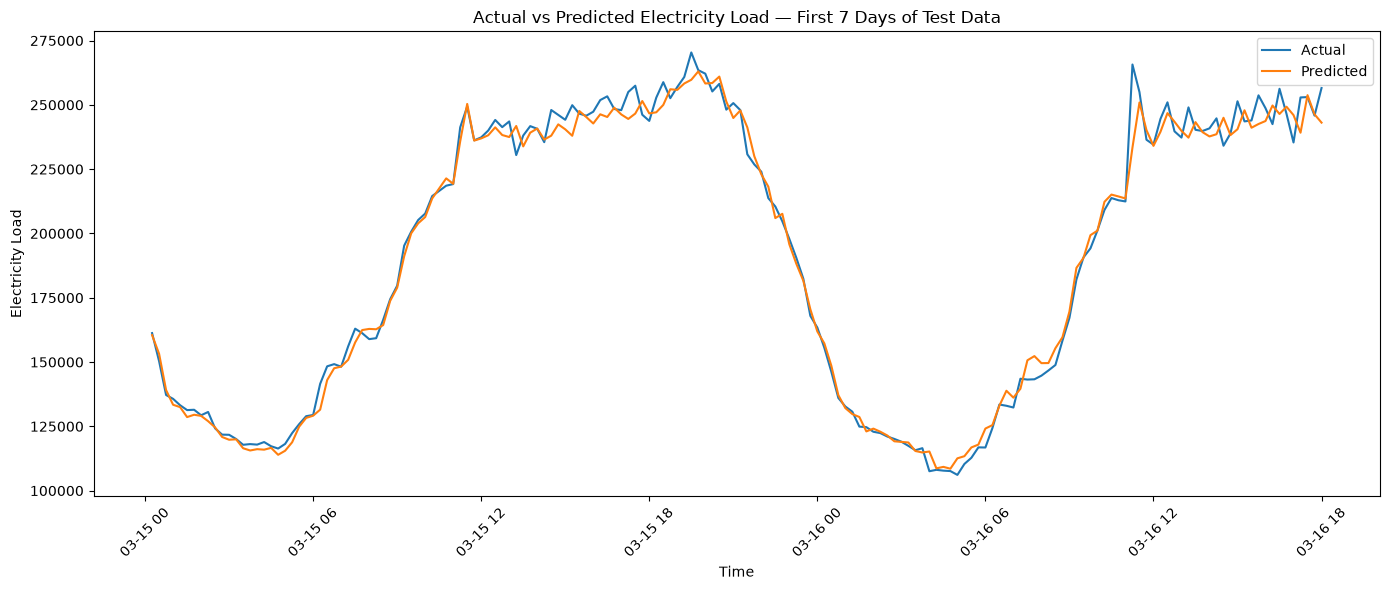

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_df["timestamp"].iloc[:24 * 7],
    y_test.iloc[:24 * 7],
    label="Actual"
)

plt.plot(
    test_df["timestamp"].iloc[:24 * 7],
    predictions[:24 * 7],
    label="Predicted"
)

plt.title("Actual vs Predicted Electricity Load — First 7 Days of Test Data")
plt.xlabel("Time")
plt.ylabel("Electricity Load")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
lag_1          0.986115
lag_96         0.009090
hour           0.001829
lag_4          0.001619
day_of_year    0.000745
day_of_week    0.000402
month          0.000144
is_weekend     0.000057
dtype: float64


In [18]:
df["rolling_mean_4"] = (
    df["total_load"]
    .shift(1)
    .rolling(4)
    .mean()
)

df["rolling_mean_96"] = (
    df["total_load"]
    .shift(1)
    .rolling(96)
    .mean()
)

df["rolling_std_96"] = (
    df["total_load"]
    .shift(1)
    .rolling(96)
    .std()
)

print(df[[
    "timestamp",
    "total_load",
    "rolling_mean_4",
    "rolling_mean_96",
    "rolling_std_96"
]].tail())

                 timestamp     total_load  rolling_mean_4  rolling_mean_96  \
140251 2014-12-31 23:00:00  132288.754939   145213.196110    183177.467331   
140252 2014-12-31 23:15:00  128543.516567   140643.249006    182523.556657   
140253 2014-12-31 23:30:00  127478.208411   135687.719398    181912.527416   
140254 2014-12-31 23:45:00  125641.710272   131333.540556    181355.072909   
140255 2015-01-01 00:00:00  124214.199215   128488.047547    180864.974326   

        rolling_std_96  
140251    47664.303619  
140252    47929.385817  
140253    48241.997861  
140254    48560.868212  
140255    48885.565548  


C:\Users\nimra\AppData\Local\Temp\ipykernel_15768\4050797188.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["rolling_mean_4"] = (
C:\Users\nimra\AppData\Local\Temp\ipykernel_15768\4050797188.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["rolling_mean_96"] = (
C:\Users\nimra\AppData\Local\Temp\ipykernel_15768\4050797188.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using

In [19]:
model_columns_v2 = [
    "timestamp",
    "total_load",
    "hour",
    "day_of_week",
    "day_of_year",
    "month",
    "is_weekend",
    "lag_1",
    "lag_4",
    "lag_96",
    "rolling_mean_4",
    "rolling_mean_96",
    "rolling_std_96"
]

model_df_v2 = df[model_columns_v2].copy()

model_df_v2 = model_df_v2.dropna()
model_df_v2 = model_df_v2.reset_index(drop=True)

print("New modeling dataset shape:", model_df_v2.shape)

print("\nMissing values:")
print(model_df_v2.isnull().sum())

New modeling dataset shape: (140160, 13)

Missing values:
timestamp          0
total_load         0
hour               0
day_of_week        0
day_of_year        0
month              0
is_weekend         0
lag_1              0
lag_4              0
lag_96             0
rolling_mean_4     0
rolling_mean_96    0
rolling_std_96     0
dtype: int64


In [20]:
split_index_v2 = int(len(model_df_v2) * 0.8)

train_df_v2 = model_df_v2.iloc[:split_index_v2].copy()
test_df_v2 = model_df_v2.iloc[split_index_v2:].copy()

print("Training data:")
print("Rows:", len(train_df_v2))
print("Start:", train_df_v2["timestamp"].min())
print("End:", train_df_v2["timestamp"].max())

print("\nTesting data:")
print("Rows:", len(test_df_v2))
print("Start:", test_df_v2["timestamp"].min())
print("End:", test_df_v2["timestamp"].max())

Training data:
Rows: 112128
Start: 2011-01-02 00:15:00
End: 2014-03-15 00:00:00

Testing data:
Rows: 28032
Start: 2014-03-15 00:15:00
End: 2015-01-01 00:00:00


In [21]:
features_v2 = [
    "hour",
    "day_of_week",
    "day_of_year",
    "month",
    "is_weekend",
    "lag_1",
    "lag_4",
    "lag_96",
    "rolling_mean_4",
    "rolling_mean_96",
    "rolling_std_96"
]

X_train_v2 = train_df_v2[features_v2]
y_train_v2 = train_df_v2["total_load"]

X_test_v2 = test_df_v2[features_v2]
y_test_v2 = test_df_v2["total_load"]

model_v2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_v2.fit(X_train_v2, y_train_v2)

predictions_v2 = model_v2.predict(X_test_v2)

mae_v2 = mean_absolute_error(y_test_v2, predictions_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test_v2, predictions_v2))

print("Improved Random Forest Results")
print("--------------------------------")
print("MAE :", mae_v2)
print("RMSE:", rmse_v2)

Improved Random Forest Results
--------------------------------
MAE : 4230.1152870378455
RMSE: 6451.624945408012


In [22]:
feature_importance_v2 = pd.Series(
    model_v2.feature_importances_,
    index=features_v2
).sort_values(ascending=False)

print("Improved Model Feature Importance:")
print(feature_importance_v2)

Improved Model Feature Importance:
lag_1              0.985686
lag_96             0.008628
hour               0.001510
lag_4              0.000944
rolling_mean_96    0.000921
rolling_mean_4     0.000896
rolling_std_96     0.000622
day_of_year        0.000403
day_of_week        0.000268
month              0.000084
is_weekend         0.000039
dtype: float64


In [23]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["day_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

print(df[[
    "timestamp",
    "hour",
    "hour_sin",
    "hour_cos",
    "day_of_week",
    "day_sin",
    "day_cos"
]].head(10))

            timestamp  hour  hour_sin  hour_cos  day_of_week   day_sin  \
0 2011-01-01 00:15:00     0  0.000000  1.000000            5 -0.974928   
1 2011-01-01 00:30:00     0  0.000000  1.000000            5 -0.974928   
2 2011-01-01 00:45:00     0  0.000000  1.000000            5 -0.974928   
3 2011-01-01 01:00:00     1  0.258819  0.965926            5 -0.974928   
4 2011-01-01 01:15:00     1  0.258819  0.965926            5 -0.974928   
5 2011-01-01 01:30:00     1  0.258819  0.965926            5 -0.974928   
6 2011-01-01 01:45:00     1  0.258819  0.965926            5 -0.974928   
7 2011-01-01 02:00:00     2  0.500000  0.866025            5 -0.974928   
8 2011-01-01 02:15:00     2  0.500000  0.866025            5 -0.974928   
9 2011-01-01 02:30:00     2  0.500000  0.866025            5 -0.974928   

    day_cos  
0 -0.222521  
1 -0.222521  
2 -0.222521  
3 -0.222521  
4 -0.222521  
5 -0.222521  
6 -0.222521  
7 -0.222521  
8 -0.222521  
9 -0.222521  


C:\Users\nimra\AppData\Local\Temp\ipykernel_15768\341441331.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
C:\Users\nimra\AppData\Local\Temp\ipykernel_15768\341441331.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
C:\Users\nimra\AppData\Local\Temp\ipykernel_15768\341441331.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

In [24]:
model_columns_v3 = [
    "timestamp",
    "total_load",
    "hour",
    "day_of_week",
    "day_of_year",
    "month",
    "is_weekend",
    "lag_1",
    "lag_4",
    "lag_96",
    "rolling_mean_4",
    "rolling_mean_96",
    "rolling_std_96",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos"
]

model_df_v3 = df[model_columns_v3].copy()

model_df_v3 = model_df_v3.dropna()
model_df_v3 = model_df_v3.reset_index(drop=True)

print("Final feature dataset shape:", model_df_v3.shape)

print("\nMissing values:")
print(model_df_v3.isnull().sum())

Final feature dataset shape: (140160, 17)

Missing values:
timestamp          0
total_load         0
hour               0
day_of_week        0
day_of_year        0
month              0
is_weekend         0
lag_1              0
lag_4              0
lag_96             0
rolling_mean_4     0
rolling_mean_96    0
rolling_std_96     0
hour_sin           0
hour_cos           0
day_sin            0
day_cos            0
dtype: int64


In [25]:
split_index_v3 = int(len(model_df_v3) * 0.8)

train_df_v3 = model_df_v3.iloc[:split_index_v3].copy()
test_df_v3 = model_df_v3.iloc[split_index_v3:].copy()

print("Training data:")
print("Rows:", len(train_df_v3))
print("Start:", train_df_v3["timestamp"].min())
print("End:", train_df_v3["timestamp"].max())

print("\nTesting data:")
print("Rows:", len(test_df_v3))
print("Start:", test_df_v3["timestamp"].min())
print("End:", test_df_v3["timestamp"].max())

Training data:
Rows: 112128
Start: 2011-01-02 00:15:00
End: 2014-03-15 00:00:00

Testing data:
Rows: 28032
Start: 2014-03-15 00:15:00
End: 2015-01-01 00:00:00


In [26]:
features_v3 = [
    "hour",
    "day_of_week",
    "day_of_year",
    "month",
    "is_weekend",
    "lag_1",
    "lag_4",
    "lag_96",
    "rolling_mean_4",
    "rolling_mean_96",
    "rolling_std_96",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos"
]

X_train_v3 = train_df_v3[features_v3]
y_train_v3 = train_df_v3["total_load"]

X_test_v3 = test_df_v3[features_v3]
y_test_v3 = test_df_v3["total_load"]

model_v3 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_v3.fit(X_train_v3, y_train_v3)

predictions_v3 = model_v3.predict(X_test_v3)

mae_v3 = mean_absolute_error(y_test_v3, predictions_v3)
rmse_v3 = np.sqrt(mean_squared_error(y_test_v3, predictions_v3))

print("Final Random Forest Results")
print("----------------------------")
print("MAE :", mae_v3)
print("RMSE:", rmse_v3)

Final Random Forest Results
----------------------------
MAE : 4235.204598071072
RMSE: 6455.473654900943


In [27]:
mae_improvement_v2 = ((baseline_mae - mae_v2) / baseline_mae) * 100
rmse_improvement_v2 = ((baseline_rmse - rmse_v2) / baseline_rmse) * 100

print("Winning Model: Improved Random Forest")
print("--------------------------------------")
print("MAE :", round(mae_v2, 2))
print("RMSE:", round(rmse_v2, 2))
print("MAE Improvement :", round(mae_improvement_v2, 2), "%")
print("RMSE Improvement:", round(rmse_improvement_v2, 2), "%")

Winning Model: Improved Random Forest
--------------------------------------
MAE : 4230.12
RMSE: 6451.62
MAE Improvement : 53.22 %
RMSE Improvement: 55.29 %


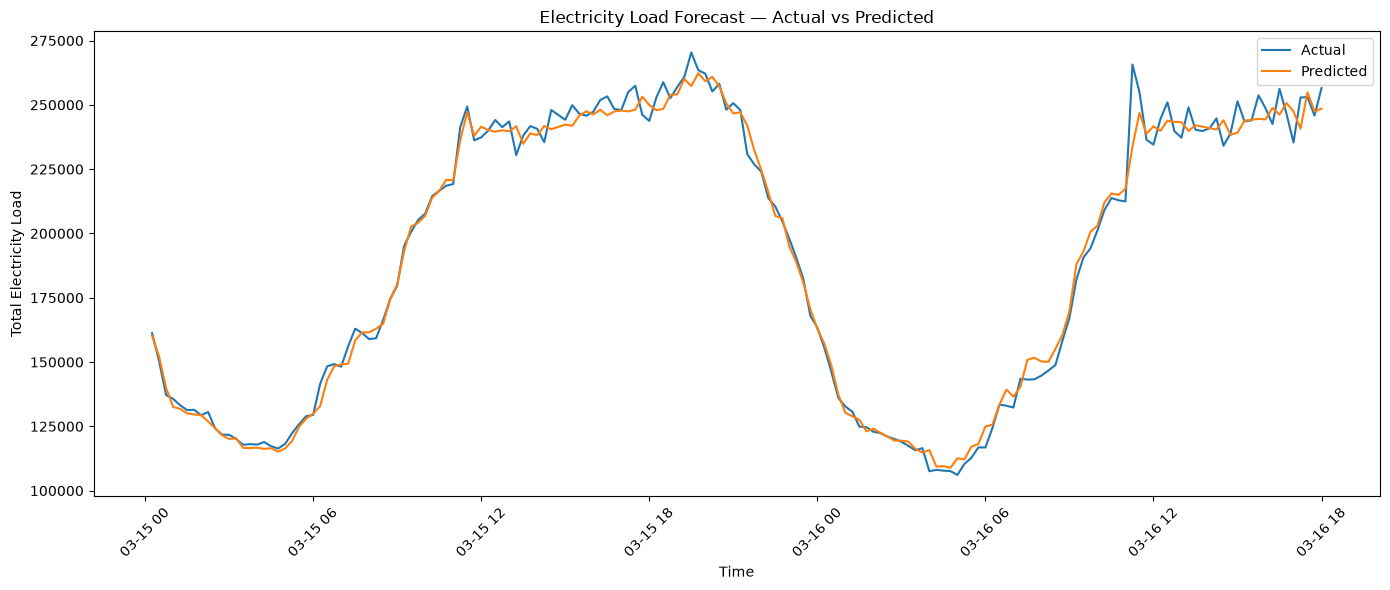

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_df_v2["timestamp"].iloc[:24 * 7],
    y_test_v2.iloc[:24 * 7],
    label="Actual"
)

plt.plot(
    test_df_v2["timestamp"].iloc[:24 * 7],
    predictions_v2[:24 * 7],
    label="Predicted"
)

plt.title("Electricity Load Forecast — Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Total Electricity Load")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
results_df = pd.DataFrame({
    "timestamp": test_df_v2["timestamp"],
    "actual_load": y_test_v2,
    "predicted_load": predictions_v2
})

results_df["absolute_error"] = (
    results_df["actual_load"] - results_df["predicted_load"]
).abs()

print(results_df.head(10))

                 timestamp    actual_load  predicted_load  absolute_error
112128 2014-03-15 00:15:00  161258.625082   160279.234124      979.390958
112129 2014-03-15 00:30:00  150339.791069   152125.410341     1785.619272
112130 2014-03-15 00:45:00  137183.594633   140005.131635     2821.537001
112131 2014-03-15 01:00:00  135691.014016   132561.445909     3129.568107
112132 2014-03-15 01:15:00  133213.870997   131812.864428     1401.006569
112133 2014-03-15 01:30:00  131319.489170   130045.567176     1273.921994
112134 2014-03-15 01:45:00  131449.741992   129622.321474     1827.420518
112135 2014-03-15 02:00:00  129312.359476   129359.254715       46.895239
112136 2014-03-15 02:15:00  130589.791825   126920.807105     3668.984720
112137 2014-03-15 02:30:00  124205.784947   124262.925144       57.140197


In [30]:
results_df.to_csv(
    "../outputs/electricity_load_predictions.csv",
    index=False
)

print("Prediction results saved successfully!")
print("Rows saved:", len(results_df))

Prediction results saved successfully!
Rows saved: 28032


In [31]:
import joblib

joblib.dump(
    model_v2,
    "../outputs/electricity_load_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [32]:
evaluation_summary = pd.DataFrame({
    "Model": [
        "Previous-Day Baseline",
        "Random Forest",
        "Improved Random Forest"
    ],
    "MAE": [
        baseline_mae,
        mae,
        mae_v2
    ],
    "RMSE": [
        baseline_rmse,
        rmse,
        rmse_v2
    ]
})

print(evaluation_summary)

                    Model          MAE          RMSE
0   Previous-Day Baseline  9043.197221  14431.270391
1           Random Forest  4419.169554   6743.079422
2  Improved Random Forest  4230.115287   6451.624945


In [33]:
evaluation_summary.to_csv(
    "../outputs/model_evaluation.csv",
    index=False
)

print("Evaluation summary saved successfully!")

Evaluation summary saved successfully!
